<a href="https://colab.research.google.com/github/BrajanNieto/CompuVision/blob/main/CV_Labo2_ImageClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Computer Vision - Segmentación de imágenes y detección de bordes**

---



*   Este notebook se enfoca en aplicar técnicas fundamentales de visión por computadora para el procesamiento de imágenes. Incluye tres tareas principales: segmentación basada en color de frutas, detección de bordes en imágenes médicas de rayos X, y segmentación de señales de tráfico combinando umbrales de color y métodos de detección de bordes. El objetivo es practicar transformaciones RGB/HSV, filtrado y operadores clásicos como Sobel y Canny.

**Autores:**  

Nieto Espinoza, Brajan E.  
[brajan.nieto@utec.edu.pe](mailto:brajan.nieto@utec.edu.pe)

Guedes del Pozo,  Rodrigo J.  
[rodrigo.guedes.d@utec.edu.pe](mailto:rodrigo.guedes.d@utec.edu.pe)

<img src="https://pregrado.utec.edu.pe/sites/default/files/logo-utec-h_0_0.svg" width="190" alt="Logo UTEC" loading="lazy" typeof="foaf:Image">      

---

In [ ]:
# === Libraries===
import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen

### 1. Cargar la imagen y visualizarla en el formato RGB correcto.

In [1]:
# ============================================================
# CELDA 1 (EJECUTAR PRIMERO)
# Objetivo:
# 1) Cargar CIFAR-10 con cifar10.load_data() (valores por defecto).
# 2) Quedarnos SOLO con 3 clases (configurables abajo).
# 3) Separar el conjunto resultante en 80% train y 20% test (estratificado).
#
# Instrucciones:
# - Ejecuta esta celda una vez. Cambia SELECTED_CLASSES si quieres otras 3.
# - Por defecto se usan: 0=airplane, 1=automobile, 8=ship.
# ============================================================

import numpy as np
import random
import cv2
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Cargar CIFAR-10 (por defecto: (50000 train, 10000 test) de 10 clases)
(X_train_full, y_train_full), (X_test_full, y_test_full) = cifar10.load_data()

# Elegimos 3 clases (puedes cambiarlas)
# 0='airplane',1='automobile',2='bird',3='cat',4='deer',
# 5='dog',6='frog',7='horse',8='ship',9='truck'
SELECTED_CLASSES = [0, 1, 8]  # airplane, automobile, ship

CLASS_NAMES = {
    0:'airplane', 1:'automobile', 2:'bird', 3:'cat', 4:'deer',
    5:'dog', 6:'frog', 7:'horse', 8:'ship', 9:'truck'
}

# Usaremos SOLO el split de entrenamiento original de Keras
X_full = X_train_full
y_full = y_train_full.flatten()

# Filtrar a las 3 clases elegidas
mask = np.isin(y_full, SELECTED_CLASSES)
X = X_full[mask]
y = y_full[mask]

# (Opcional) Si quieres limitar muestras por clase para acelerar, define N_PER_CLASS (ej. 2000). None = usar todas.
N_PER_CLASS = None
if N_PER_CLASS is not None:
    X_sel, y_sel = [], []
    for c in SELECTED_CLASSES:
        idx_c = np.where(y == c)[0]
        np.random.shuffle(idx_c)
        idx_c = idx_c[:N_PER_CLASS]
        X_sel.append(X[idx_c])
        y_sel.append(y[idx_c])
    X = np.concatenate(X_sel, axis=0)
    y = np.concatenate(y_sel, axis=0)

# Separación 80/20 estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# Info
def dist_clases(vec):
    uniques, counts = np.unique(vec, return_counts=True)
    return {CLASS_NAMES[int(k)]: int(v) for k, v in zip(uniques, counts)}

print("Clases seleccionadas:", [f"{c}={CLASS_NAMES[c]}" for c in SELECTED_CLASSES])
print("Dimensiones X_train:", X_train.shape, "X_test:", X_test.shape)
print("Distribución train:", dist_clases(y_train))
print("Distribución test :", dist_clases(y_test))


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Clases seleccionadas: ['0=airplane', '1=automobile', '8=ship']
Dimensiones X_train: (12000, 32, 32, 3) X_test: (3000, 32, 32, 3)
Distribución train: {'airplane': 4000, 'automobile': 4000, 'ship': 4000}
Distribución test : {'airplane': 1000, 'automobile': 1000, 'ship': 1000}


### 2. Convertir la imagen a un espacio de color HSV.

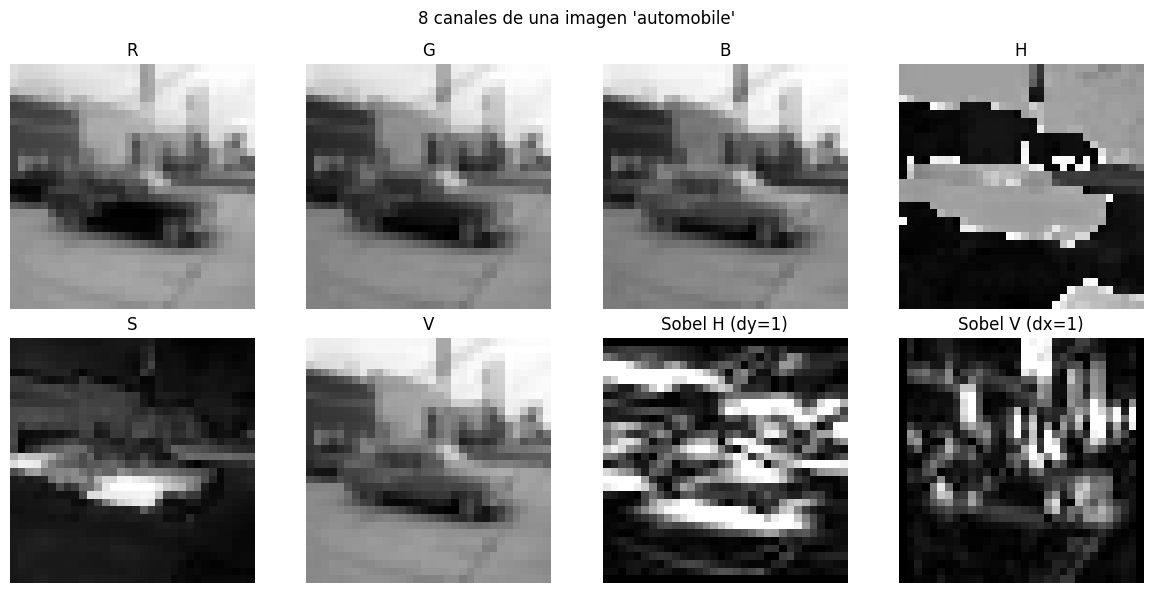

Extrayendo características (esto puede tardar un poco)...
X_train_feat: (12000, 8192) X_test_feat: (3000, 8192)


In [2]:
# ============================================================
# CELDA 2
# Objetivo:
# 1) Definir una función que extraiga 8 características por imagen:
#    R, G, B, H, S, V, bordes Sobel horizontales y verticales.
# 2) Visualizar estos 8 "canales" para UNA imagen aleatoria.
# 3) Construir matrices de características para train y test.
#
# Instrucciones:
# - Ejecuta esta celda después de la Celda 1.
# - Cambia SHOW_INDEX si quieres ver otra imagen.
# ============================================================

import numpy as np
import cv2
import matplotlib.pyplot as plt

def extract_8_features(img_rgb):
    """
    img_rgb: (32,32,3) uint8 en espacio RGB.
    Retorna un vector 1D con la concatenación de:
    [R, G, B, H, S, V, Sobel_H (dy=1), Sobel_V (dx=1)]  (todos aplanados).
    """
    # Canales RGB
    R = img_rgb[:, :, 0].astype(np.float32)
    G = img_rgb[:, :, 1].astype(np.float32)
    B = img_rgb[:, :, 2].astype(np.float32)

    # HSV (OpenCV espera RGB->HSV con cv2.COLOR_RGB2HSV)
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    H = hsv[:, :, 0].astype(np.float32)   # [0..179] en OpenCV
    S = hsv[:, :, 1].astype(np.float32)   # [0..255]
    V = hsv[:, :, 2].astype(np.float32)   # [0..255]

    # Bordes Sobel en escala de grises
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY).astype(np.float32)
    sobel_h = cv2.Sobel(gray, ddepth=cv2.CV_64F, dx=0, dy=1, ksize=3)  # cambios horizontales
    sobel_v = cv2.Sobel(gray, ddepth=cv2.CV_64F, dx=1, dy=0, ksize=3)  # cambios verticales
    sobel_h = cv2.convertScaleAbs(sobel_h).astype(np.float32)
    sobel_v = cv2.convertScaleAbs(sobel_v).astype(np.float32)

    # Concatenar y aplanar
    feats = np.stack([R, G, B, H, S, V, sobel_h, sobel_v], axis=0)  # (8, 32, 32)
    return feats.reshape(-1)  # (8*32*32,)

def batch_extract_features(X):
    return np.vstack([extract_8_features(img) for img in X])

# Visualización de los 8 canales para 1 imagen aleatoria del set de entrenamiento
SHOW_INDEX = np.random.randint(0, len(X_train))
img = X_train[SHOW_INDEX]

R = img[:, :, 0]
G = img[:, :, 1]
B = img[:, :, 2]
hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
Hc, Sc, Vc = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
sobel_h = cv2.convertScaleAbs(cv2.Sobel(gray, ddepth=cv2.CV_64F, dx=0, dy=1, ksize=3))
sobel_v = cv2.convertScaleAbs(cv2.Sobel(gray, ddepth=cv2.CV_64F, dx=1, dy=0, ksize=3))

titles = ["R", "G", "B", "H", "S", "V", "Sobel H (dy=1)", "Sobel V (dx=1)"]
planes = [R, G, B, Hc, Sc, Vc, sobel_h, sobel_v]

plt.figure(figsize=(12, 6))
for i, (t, p) in enumerate(zip(titles, planes)):
    ax = plt.subplot(2, 4, i+1)
    ax.imshow(p, cmap='gray')
    ax.set_title(t)
    ax.axis('off')
plt.suptitle(f"8 canales de una imagen '{CLASS_NAMES[int(y_train[SHOW_INDEX])]}'")
plt.tight_layout()
plt.show()

# Construir features para train y test
print("Extrayendo características (esto puede tardar un poco)...")
X_train_feat = batch_extract_features(X_train)
X_test_feat  = batch_extract_features(X_test)
print("X_train_feat:", X_train_feat.shape, "X_test_feat:", X_test_feat.shape)


### 3. Visualizar las bandas R, G, B, H, S, y V.

In [ ]:
# ============================================================
# CELDA 3 (ACTUALIZADA)
# Objetivo:
# 3.1 Hacer un GRID SEARCH "manual" sobre Regresión Logística:
#     - Calcular cuántas combinaciones hay y mostrar progreso i/total
#       mientras se evalúa cada set de hiperparámetros (CV=3) con
#       métricas: accuracy y f1_macro.
#     - Imprimir TOP-5 de CV por cada métrica.
#     - Reentrenar el mejor por accuracy y el mejor por f1_macro,
#       evaluar en TEST (classification_report + matriz de confusión).
#     - Elegir modelo final según METRICA_DECISION y avisar.
# 3.2 Con el mejor, mostrar 15 imágenes aleatorias del TEST con su
#     predicción e indicar si acierta o no en el título.
#
# Instrucciones:
# - Ejecuta después de la Celda 2.
# - Puedes cambiar METRICA_DECISION a 'accuracy' o 'f1_macro'.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import ParameterGrid, cross_validate, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.base import clone

METRICA_DECISION = 'accuracy'  # 'accuracy' o 'f1_macro'

# Pipeline base
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=2000, multi_class='ovr'))
])

# Espacio de búsqueda (30 combinaciones)
param_grid_lr = {
    'logreg__C': [0.01, 0.1, 1, 10, 100],
    'logreg__solver': ['liblinear', 'lbfgs', 'saga'],
    'logreg__penalty': ['l2'],
    'logreg__class_weight': [None, 'balanced'],
}

scoring = {'accuracy': 'accuracy', 'f1_macro': 'f1_macro'}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid = list(ParameterGrid(param_grid_lr))
total = len(grid)
print(f"[LR] Combinaciones totales: {total}\n")

all_results_lr = []

for i, params in enumerate(grid, start=1):
    est = clone(pipe_lr).set_params(**params)
    cv_res = cross_validate(
        est, X_train_feat, y_train,
        scoring=scoring, cv=cv, n_jobs=-1, return_train_score=False
    )
    mean_acc = float(np.mean(cv_res['test_accuracy']))
    mean_f1  = float(np.mean(cv_res['test_f1_macro']))
    all_results_lr.append({'params': params, 'mean_accuracy': mean_acc, 'mean_f1_macro': mean_f1})
    print(f"[LR] {i}/{total} -> acc={mean_acc:.4f} | f1_macro={mean_f1:.4f} | params={params}")

# ---- Resumen final TOP-5 por métrica (CV) ----
def top_k(results, key, k=5):
    return sorted(results, key=lambda d: d[key], reverse=True)[:k]

print("\n=== [LR] TOP-5 (CV) por accuracy ===")
for r in top_k(all_results_lr, 'mean_accuracy'):
    print({'mean_accuracy': round(r['mean_accuracy'], 4), 'params': r['params']})

print("\n=== [LR] TOP-5 (CV) por f1_macro ===")
for r in top_k(all_results_lr, 'mean_f1_macro'):
    print({'mean_f1_macro': round(r['mean_f1_macro'], 4), 'params': r['params']})

# ---- Reentrenar mejores y evaluar en TEST ----
best_acc = max(all_results_lr, key=lambda d: d['mean_accuracy'])
best_f1  = max(all_results_lr, key=lambda d: d['mean_f1_macro'])

best_acc_est = clone(pipe_lr).set_params(**best_acc['params']).fit(X_train_feat, y_train)
y_pred_acc = best_acc_est.predict(X_test_feat)

print("\n=== LOGISTIC REGRESSION — Mejor por ACCURACY (en TEST) ===")
print(classification_report(y_test, y_pred_acc, target_names=[CLASS_NAMES[c] for c in SELECTED_CLASSES]))

cm_acc = confusion_matrix(y_test, y_pred_acc, labels=SELECTED_CLASSES)
plt.figure(figsize=(4,4))
plt.imshow(cm_acc, interpolation='nearest')
plt.title('Matriz de confusión (LR mejor por accuracy)')
plt.xticks(range(len(SELECTED_CLASSES)), [CLASS_NAMES[c] for c in SELECTED_CLASSES], rotation=45)
plt.yticks(range(len(SELECTED_CLASSES)), [CLASS_NAMES[c] for c in SELECTED_CLASSES])
plt.colorbar()
plt.tight_layout()
plt.show()

best_f1_est = clone(pipe_lr).set_params(**best_f1['params']).fit(X_train_feat, y_train)
y_pred_f1 = best_f1_est.predict(X_test_feat)

print("\n=== LOGISTIC REGRESSION — Mejor por F1_MACRO (en TEST) ===")
print(classification_report(y_test, y_pred_f1, target_names=[CLASS_NAMES[c] for c in SELECTED_CLASSES]))

cm_f1 = confusion_matrix(y_test, y_pred_f1, labels=SELECTED_CLASSES)
plt.figure(figsize=(4,4))
plt.imshow(cm_f1, interpolation='nearest')
plt.title('Matriz de confusión (LR mejor por f1_macro)')
plt.xticks(range(len(SELECTED_CLASSES)), [CLASS_NAMES[c] for c in SELECTED_CLASSES], rotation=45)
plt.yticks(range(len(SELECTED_CLASSES)), [CLASS_NAMES[c] for c in SELECTED_CLASSES])
plt.colorbar()
plt.tight_layout()
plt.show()

# ---- Elegir modelo final para 3.2 ----
if METRICA_DECISION == 'f1_macro':
    best_lr = best_f1_est
    y_pred_best = y_pred_f1
    tag_best = "F1_MACRO"
else:
    best_lr = best_acc_est
    y_pred_best = y_pred_acc
    tag_best = "ACCURACY"

print(f">>> Para (3.2) usamos el modelo LR con MEJOR {tag_best} en TEST.")
print(f">>> Mejor por accuracy (CV): {best_acc['mean_accuracy']:.4f} | params={best_acc['params']}")
print(f">>> Mejor por f1_macro (CV): {best_f1['mean_f1_macro']:.4f} | params={best_f1['params']}")

# ---- 3.2: Visualización de 15 imágenes del TEST ----
n_vis = 15
idxs = np.random.choice(len(X_test), size=n_vis, replace=False)

plt.figure(figsize=(12, 7))
for i, idx in enumerate(idxs, 1):
    img = X_test[idx]
    true_c = int(y_test[idx])
    pred_c = int(y_pred_best[idx])
    correcto = (true_c == pred_c)
    titulo = f"Pred: {CLASS_NAMES[pred_c]} {'✓' if correcto else '✗'}\nTrue: {CLASS_NAMES[true_c]}"
    ax = plt.subplot(3, 5, i)
    ax.imshow(img)
    ax.set_title(titulo, fontsize=9)
    ax.axis('off')
plt.suptitle("Regresión Logística — 15 muestras de TEST")
plt.tight_layout()
plt.show()


[LR] Combinaciones totales: 30

[LR] 1/30 -> acc=0.7535 | f1_macro=0.7530 | params={'logreg__C': 0.01, 'logreg__class_weight': None, 'logreg__penalty': 'l2', 'logreg__solver': 'liblinear'}
[LR] 2/30 -> acc=0.7578 | f1_macro=0.7576 | params={'logreg__C': 0.01, 'logreg__class_weight': None, 'logreg__penalty': 'l2', 'logreg__solver': 'lbfgs'}
[LR] 3/30 -> acc=0.7579 | f1_macro=0.7576 | params={'logreg__C': 0.01, 'logreg__class_weight': None, 'logreg__penalty': 'l2', 'logreg__solver': 'saga'}
[LR] 4/30 -> acc=0.7535 | f1_macro=0.7530 | params={'logreg__C': 0.01, 'logreg__class_weight': 'balanced', 'logreg__penalty': 'l2', 'logreg__solver': 'liblinear'}
[LR] 5/30 -> acc=0.7562 | f1_macro=0.7561 | params={'logreg__C': 0.01, 'logreg__class_weight': 'balanced', 'logreg__penalty': 'l2', 'logreg__solver': 'lbfgs'}
[LR] 6/30 -> acc=0.7564 | f1_macro=0.7562 | params={'logreg__C': 0.01, 'logreg__class_weight': 'balanced', 'logreg__penalty': 'l2', 'logreg__solver': 'saga'}
[LR] 7/30 -> acc=0.7250 | 

###4. Experimentar con diferentes umbrales en las bandas para poder segmentar de la mejor forma una de las frutas mencionadas.

[KNN] Combinaciones totales: 24

[KNN] 1/24 -> acc=0.6263 | f1_macro=0.6137 | params={'knn__leaf_size': 15, 'knn__n_neighbors': 3, 'knn__p': 1, 'knn__weights': 'uniform'}
[KNN] 2/24 -> acc=0.6397 | f1_macro=0.6315 | params={'knn__leaf_size': 15, 'knn__n_neighbors': 3, 'knn__p': 1, 'knn__weights': 'distance'}
[KNN] 3/24 -> acc=0.5907 | f1_macro=0.5673 | params={'knn__leaf_size': 15, 'knn__n_neighbors': 3, 'knn__p': 2, 'knn__weights': 'uniform'}
[KNN] 4/24 -> acc=0.6062 | f1_macro=0.5903 | params={'knn__leaf_size': 15, 'knn__n_neighbors': 3, 'knn__p': 2, 'knn__weights': 'distance'}
[KNN] 5/24 -> acc=0.6349 | f1_macro=0.6224 | params={'knn__leaf_size': 15, 'knn__n_neighbors': 5, 'knn__p': 1, 'knn__weights': 'uniform'}
[KNN] 6/24 -> acc=0.6408 | f1_macro=0.6297 | params={'knn__leaf_size': 15, 'knn__n_neighbors': 5, 'knn__p': 1, 'knn__weights': 'distance'}
[KNN] 7/24 -> acc=0.6065 | f1_macro=0.5857 | params={'knn__leaf_size': 15, 'knn__n_neighbors': 5, 'knn__p': 2, 'knn__weights': 'uniform'

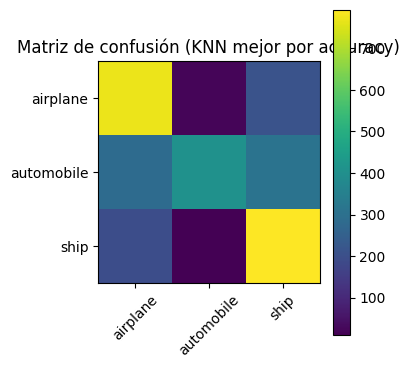


=== KNN — Mejor por F1_MACRO (en TEST) ===
              precision    recall  f1-score   support

    airplane       0.62      0.77      0.69      1000
  automobile       0.91      0.41      0.57      1000
        ship       0.60      0.79      0.68      1000

    accuracy                           0.65      3000
   macro avg       0.71      0.65      0.64      3000
weighted avg       0.71      0.65      0.64      3000



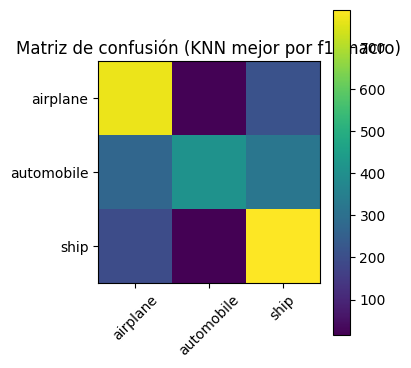

>>> Para (4.2) usamos el modelo KNN con MEJOR ACCURACY en TEST.
>>> Mejor por accuracy (CV): 0.6408 | params={'knn__leaf_size': 15, 'knn__n_neighbors': 5, 'knn__p': 1, 'knn__weights': 'distance'}
>>> Mejor por f1_macro (CV): 0.6315 | params={'knn__leaf_size': 15, 'knn__n_neighbors': 3, 'knn__p': 1, 'knn__weights': 'distance'}


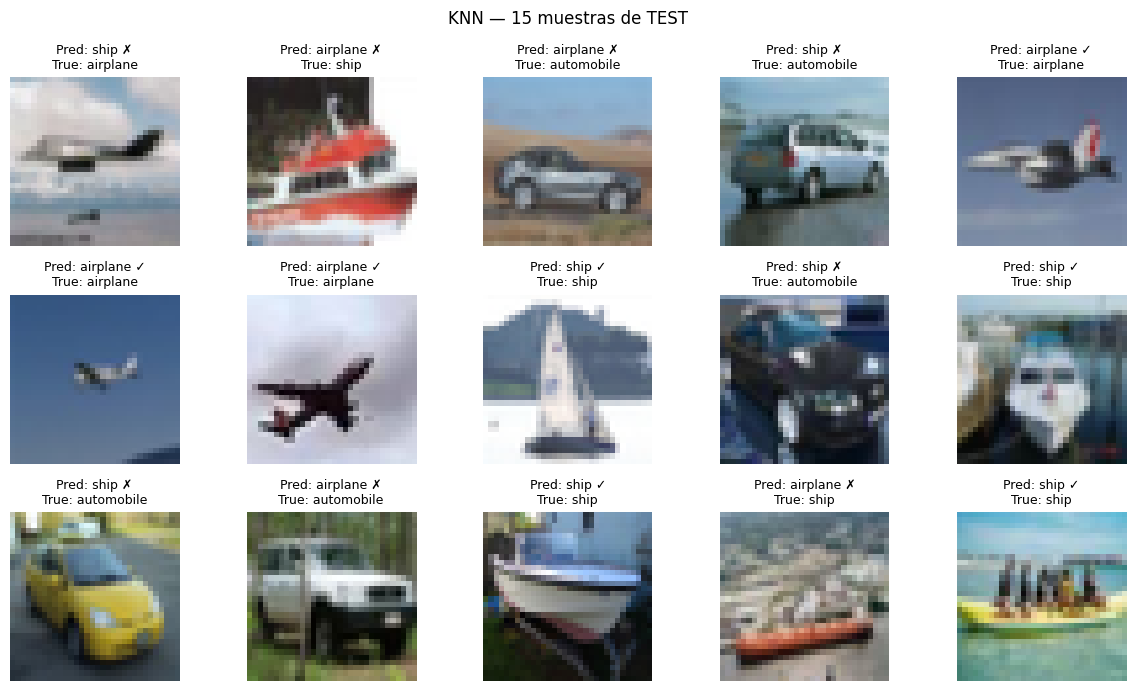

In [4]:
# ============================================================
# CELDA 4 (ACTUALIZADA)
# Objetivo:
# 4.1 Hacer un GRID SEARCH "manual" sobre KNN:
#     - Calcular cuántas combinaciones hay y mostrar progreso i/total
#       mientras se evalúa cada set (CV=3) con accuracy y f1_macro.
#     - Imprimir TOP-5 de CV por cada métrica.
#     - Reentrenar el mejor por accuracy y el mejor por f1_macro,
#       evaluar en TEST (classification_report + matriz de confusión).
# 4.2 Con el mejor, mostrar 15 imágenes aleatorias del TEST con su
#     predicción e indicar si acierta o no en el título.
#
# Instrucciones:
# - Ejecuta después de la Celda 3 (o tras la 2 si quieres comparar directo).
# - Cambia METRICA_DECISION_KNN a 'accuracy' o 'f1_macro' si lo prefieres.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import ParameterGrid, cross_validate, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.base import clone

METRICA_DECISION_KNN = 'accuracy'  # 'accuracy' o 'f1_macro'

pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Espacio de búsqueda (60 combinaciones)
param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2],            # Manhattan (1) o Euclídea (2)
    'knn__leaf_size': [15, 45],
}

scoring = {'accuracy': 'accuracy', 'f1_macro': 'f1_macro'}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid = list(ParameterGrid(param_grid_knn))
total = len(grid)
print(f"[KNN] Combinaciones totales: {total}\n")

all_results_knn = []

for i, params in enumerate(grid, start=1):
    est = clone(pipe_knn).set_params(**params)
    cv_res = cross_validate(
        est, X_train_feat, y_train,
        scoring=scoring, cv=cv, n_jobs=-1, return_train_score=False
    )
    mean_acc = float(np.mean(cv_res['test_accuracy']))
    mean_f1  = float(np.mean(cv_res['test_f1_macro']))
    all_results_knn.append({'params': params, 'mean_accuracy': mean_acc, 'mean_f1_macro': mean_f1})
    print(f"[KNN] {i}/{total} -> acc={mean_acc:.4f} | f1_macro={mean_f1:.4f} | params={params}")

# ---- Resumen final TOP-5 por métrica (CV) ----
def top_k(results, key, k=5):
    return sorted(results, key=lambda d: d[key], reverse=True)[:k]

print("\n=== [KNN] TOP-5 (CV) por accuracy ===")
for r in top_k(all_results_knn, 'mean_accuracy'):
    print({'mean_accuracy': round(r['mean_accuracy'], 4), 'params': r['params']})

print("\n=== [KNN] TOP-5 (CV) por f1_macro ===")
for r in top_k(all_results_knn, 'mean_f1_macro'):
    print({'mean_f1_macro': round(r['mean_f1_macro'], 4), 'params': r['params']})

# ---- Reentrenar mejores y evaluar en TEST ----
best_acc_knn = max(all_results_knn, key=lambda d: d['mean_accuracy'])
best_f1_knn  = max(all_results_knn, key=lambda d: d['mean_f1_macro'])

best_acc_est_knn = clone(pipe_knn).set_params(**best_acc_knn['params']).fit(X_train_feat, y_train)
y_pred_acc_knn = best_acc_est_knn.predict(X_test_feat)

print("\n=== KNN — Mejor por ACCURACY (en TEST) ===")
print(classification_report(y_test, y_pred_acc_knn, target_names=[CLASS_NAMES[c] for c in SELECTED_CLASSES]))

cm_acc_knn = confusion_matrix(y_test, y_pred_acc_knn, labels=SELECTED_CLASSES)
plt.figure(figsize=(4,4))
plt.imshow(cm_acc_knn, interpolation='nearest')
plt.title('Matriz de confusión (KNN mejor por accuracy)')
plt.xticks(range(len(SELECTED_CLASSES)), [CLASS_NAMES[c] for c in SELECTED_CLASSES], rotation=45)
plt.yticks(range(len(SELECTED_CLASSES)), [CLASS_NAMES[c] for c in SELECTED_CLASSES])
plt.colorbar()
plt.tight_layout()
plt.show()

best_f1_est_knn = clone(pipe_knn).set_params(**best_f1_knn['params']).fit(X_train_feat, y_train)
y_pred_f1_knn = best_f1_est_knn.predict(X_test_feat)

print("\n=== KNN — Mejor por F1_MACRO (en TEST) ===")
print(classification_report(y_test, y_pred_f1_knn, target_names=[CLASS_NAMES[c] for c in SELECTED_CLASSES]))

cm_f1_knn = confusion_matrix(y_test, y_pred_f1_knn, labels=SELECTED_CLASSES)
plt.figure(figsize=(4,4))
plt.imshow(cm_f1_knn, interpolation='nearest')
plt.title('Matriz de confusión (KNN mejor por f1_macro)')
plt.xticks(range(len(SELECTED_CLASSES)), [CLASS_NAMES[c] for c in SELECTED_CLASSES], rotation=45)
plt.yticks(range(len(SELECTED_CLASSES)), [CLASS_NAMES[c] for c in SELECTED_CLASSES])
plt.colorbar()
plt.tight_layout()
plt.show()

# ---- Elegir modelo final para 4.2 ----
if METRICA_DECISION_KNN == 'f1_macro':
    best_knn = best_f1_est_knn
    y_pred_best_knn = y_pred_f1_knn
    tag_best_knn = "F1_MACRO"
else:
    best_knn = best_acc_est_knn
    y_pred_best_knn = y_pred_acc_knn
    tag_best_knn = "ACCURACY"

print(f">>> Para (4.2) usamos el modelo KNN con MEJOR {tag_best_knn} en TEST.")
print(f">>> Mejor por accuracy (CV): {best_acc_knn['mean_accuracy']:.4f} | params={best_acc_knn['params']}")
print(f">>> Mejor por f1_macro (CV): {best_f1_knn['mean_f1_macro']:.4f} | params={best_f1_knn['params']}")

# ---- 4.2: Visualización de 15 imágenes del TEST ----
n_vis = 15
idxs = np.random.choice(len(X_test), size=n_vis, replace=False)

plt.figure(figsize=(12, 7))
for i, idx in enumerate(idxs, 1):
    img = X_test[idx]
    true_c = int(y_test[idx])
    pred_c = int(y_pred_best_knn[idx])
    correcto = (true_c == pred_c)
    titulo = f"Pred: {CLASS_NAMES[pred_c]} {'✓' if correcto else '✗'}\nTrue: {CLASS_NAMES[true_c]}"
    ax = plt.subplot(3, 5, i)
    ax.imshow(img)
    ax.set_title(titulo, fontsize=9)
    ax.axis('off')
plt.suptitle("KNN — 15 muestras de TEST")
plt.tight_layout()
plt.show()


###5. Visualizar tanto la imagen original en formato RGB como la máscara final de segmentación de la fruta